/tmp/ipykernel_4956/3576441103.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(



Decision Tree Accuracy: 0.9853658536585366

Random Forest Accuracy: 1.0


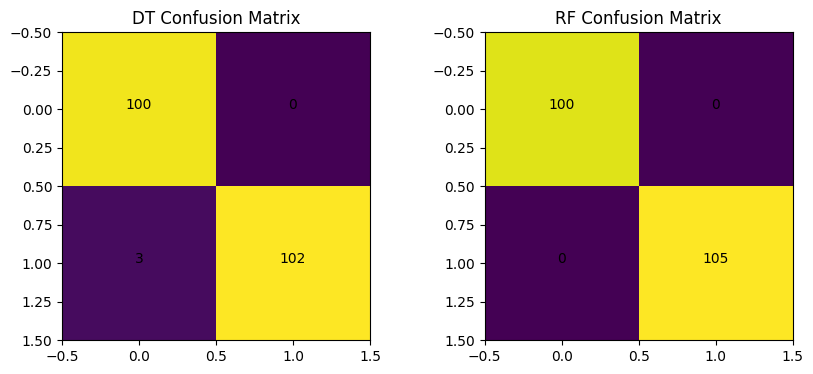

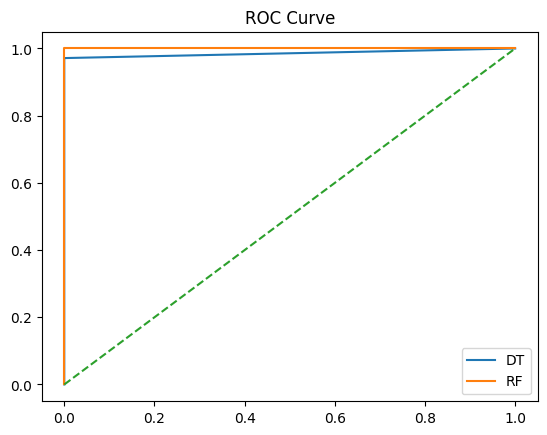

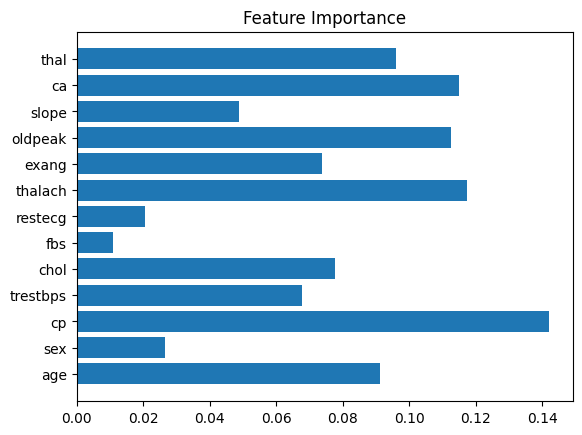

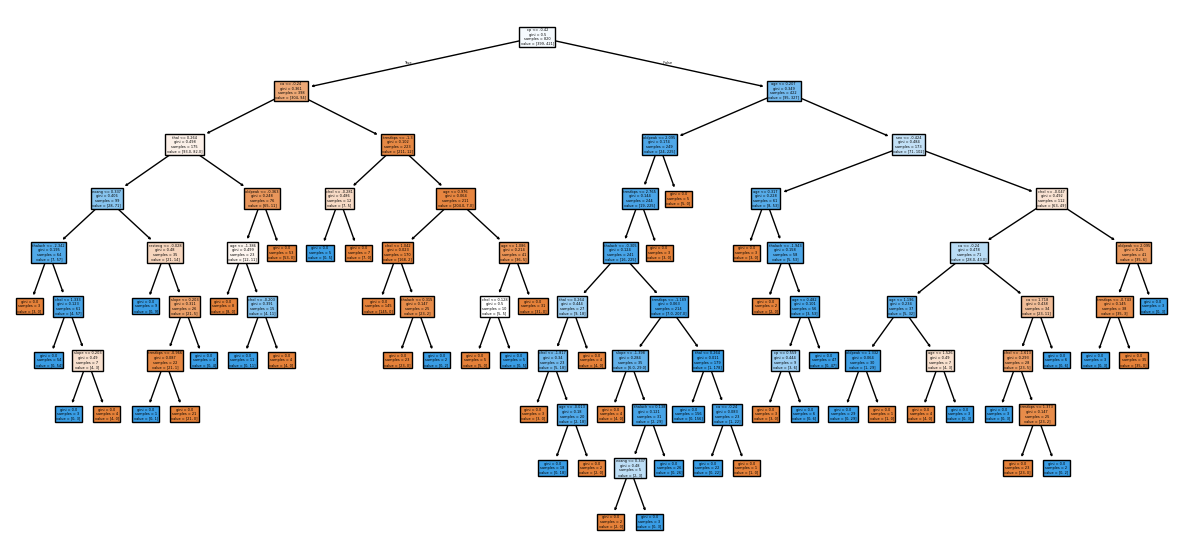

In [ ]:
# ==============================
# EXPERIMENT 3 (BASELINE)
# Decision Tree & Random Forest
# ==============================

!pip install kagglehub -q

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

# --------------------------
# Load Dataset
# --------------------------
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "johnsmith88/heart-disease-dataset",
    "heart.csv"
)

X = df.drop("target", axis=1)
y = df["target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# Decision Tree (Default)
# ==========================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:,1]

# ==========================
# Random Forest (Default)
# ==========================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

# ==========================
# Evaluation
# ==========================
print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_preds))

# ==========================
# Confusion Matrix
# ==========================
cm_dt = confusion_matrix(y_test, dt_preds)
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cm_dt)
plt.title("DT Confusion Matrix")
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm_dt[i,j],ha='center')

plt.subplot(1,2,2)
plt.imshow(cm_rf)
plt.title("RF Confusion Matrix")
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm_rf[i,j],ha='center')

plt.show()

# ==========================
# ROC Curve
# ==========================
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.plot(dt_fpr, dt_tpr, label="DT")
plt.plot(rf_fpr, rf_tpr, label="RF")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# ==========================
# Feature Importance
# ==========================
plt.barh(X.columns, rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

# ==========================
# Decision Tree Plot
# ==========================
plt.figure(figsize=(15,7))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Tuned Decision Tree Accuracy: 0.9854
Tuned Random Forest Accuracy: 1.0000


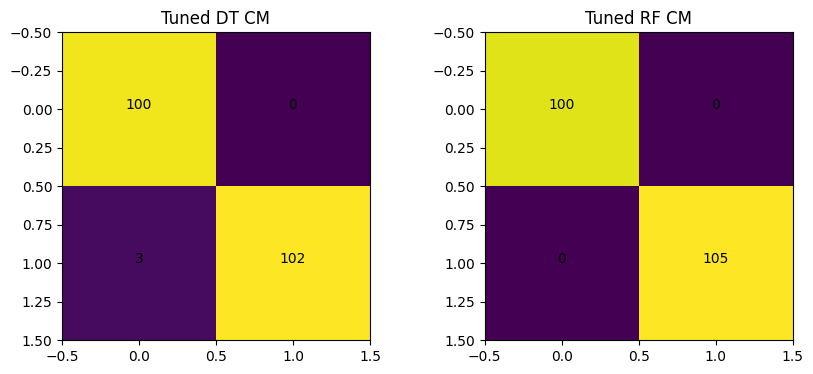

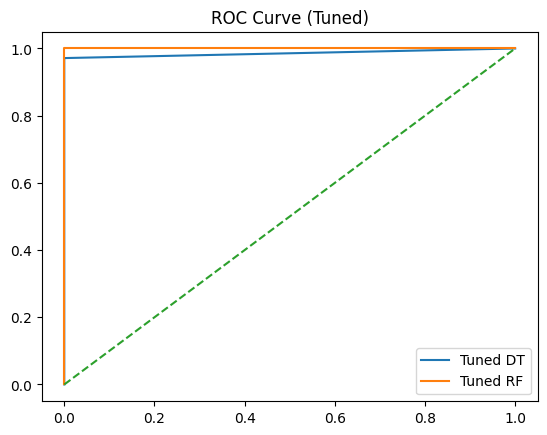

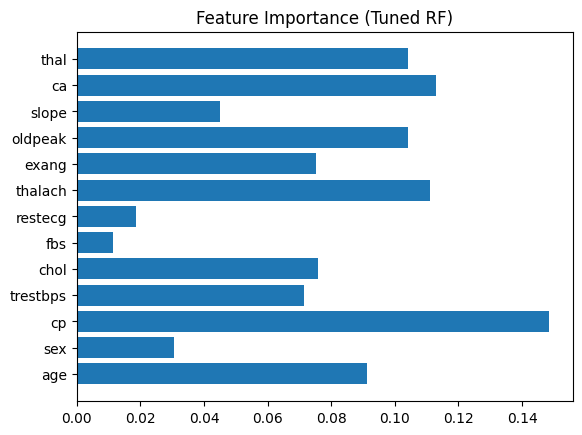

In [5]:
# ==============================
# EXPERIMENT 3 (TUNED MODEL - FULL OUTPUT)
# ==============================

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

# Load Dataset
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "johnsmith88/heart-disease-dataset",
    "heart.csv"
)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Decision Tree Tuning
dt_params = {"max_depth": [4, 6, 8, 10], "min_samples_leaf": [1, 2, 5]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

# Random Forest Tuning
rf_params = {"n_estimators": [100, 200], "max_depth": [10, 15, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

# Predictions
dt_preds = best_dt.predict(X_test)
dt_probs = best_dt.predict_proba(X_test)[:,1]
rf_preds = best_rf.predict(X_test)
rf_probs = best_rf.predict_proba(X_test)[:,1]

# Metrics Output
print(f"Tuned Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

# Confusion Matrix
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
cm_dt = confusion_matrix(y_test, dt_preds)
plt.imshow(cm_dt)
plt.title("Tuned DT CM")
for i in range(2):
    for j in range(2): plt.text(j,i,cm_dt[i,j],ha='center')

plt.subplot(1,2,2)
cm_rf = confusion_matrix(y_test, rf_preds)
plt.imshow(cm_rf)
plt.title("Tuned RF CM")
for i in range(2):
    for j in range(2): plt.text(j,i,cm_rf[i,j],ha='center')
plt.show()

# ROC Curve
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
plt.plot(dt_fpr, dt_tpr, label="Tuned DT")
plt.plot(rf_fpr, rf_tpr, label="Tuned RF")
plt.plot([0,1],[0,1],'--')
plt.legend(); plt.title("ROC Curve (Tuned)"); plt.show()

# Feature Importance
plt.barh(X.columns, best_rf.feature_importances_)
plt.title("Feature Importance (Tuned RF)"); plt.show()